In [1]:
import os
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm

from dowhy import CausalModel

c:\Users\mazza\AppData\Local\pypoetry\Cache\virtualenvs\app-17oa4emR-py3.11\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
from app.config.settings import INTERIM_DATA_DIR, PROJECT_DIR
from app.data import get_features
from app.data.utils import find_specific_variables
from app.utils.aux_functions import (
    preprocess,
    build_gml,
    compute_iptw_weights,
    compute_smd,
    ate_iptw,
    bootstrap_ci,
    ate_subgrupo
)

In [3]:
warnings.filterwarnings('ignore')
pd.set_option('display.float_format', '{:.4f}'.format)

## Carregamento dos Dados

In [4]:
df = pd.read_parquet(os.path.join(INTERIM_DATA_DIR, 'interim_dataset.parquet'))

print(df.shape)
df.head()

(95832, 30)


,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,customer_city,customer_state,...,avg_width,total_payment,avg_payment,max_installments,n_payments_type,review_score,review_score_outcome,is_delayed,purchase_weekday,purchase_month
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,sao paulo,SP,...,13.0000,38.7100,12.9033,1.0000,3.0000,4.0000,0,0,0,10
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13,barreiras,BA,...,19.0000,141.4600,141.4600,1.0000,1.0000,4.0000,0,0,1,7
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04,vianopolis,GO,...,21.0000,179.1200,179.1200,3.0000,1.0000,5.0000,0,0,2,8
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15,sao goncalo do amarante,RN,...,20.0000,72.2000,72.2000,1.0000,1.0000,5.0000,0,0,5,11
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26,santo andre,SP,...,15.0000,28.6200,28.6200,1.0000,1.0000,5.0000,0,0,1,2


In [5]:
features = get_features('features.yaml')
treatment = find_specific_variables(features, 'treatment', specific_value=True)[0]
outcome = find_specific_variables(features, 'outcome', specific_value=True)[0]
confounders = find_specific_variables(features, 'confounder', specific_value=True)

## Confundidores — Análise de Desequilíbrio Bruto

Compara as médias dos confundidores entre pedidos atrasados (T=1) e no prazo (T=0) antes do ajuste causal.  
Demonstra que os grupos não são comparáveis — validando a necessidade do IPTW.  

**Perguntas a serem respondidas:**
- *Pedidos atrasados diferem dos no prazo em características observáveis?*
- *Quais confundidores apresentam maior desequilíbrio bruto (SMD > 0.1)?*  

**obs:** 
O SMD (Standardized Mean Difference) é a métrica padrão para avaliar desequilíbrio. 
SMD > 0.1 indica que a variável distingue os grupos e precisa ser controlada.

In [6]:
df_model = df[confounders + [treatment, outcome]].dropna().copy()

smd_antes = compute_smd(df_model, confounders, treatment)

df_bruto = pd.DataFrame({
    'Média T=1': df_model.groupby(treatment)[confounders].mean().loc[1].round(3),
    'Média T=0': df_model.groupby(treatment)[confounders].mean().loc[0].round(3),
    'SMD bruto': smd_antes.round(4),
    'Desequilíbrio': smd_antes.apply(lambda x: 'YES' if x > 0.1 else 'NO')
})

df_bruto = df_bruto.sort_values('SMD bruto', ascending=False)
df_bruto

,Média T=1,Média T=0,SMD bruto,Desequilíbrio
avg_freight,22.9360,19.9430,0.1758,YES
purchase_month,5.6650,6.0570,0.1151,YES
total_freight,25.1560,22.5930,0.1142,YES
avg_weight,2455.4660,2069.5010,0.0951,NO
avg_price,140.7080,123.9230,0.0849,NO
avg_payment,171.9300,155.9050,0.0729,NO
total_payment,174.5830,158.5220,0.0724,NO
avg_length,31.1820,29.9920,0.0713,NO
n_item_distinct_categ,1.0920,1.1280,0.0673,NO
n_items,1.1100,1.1440,0.0646,NO


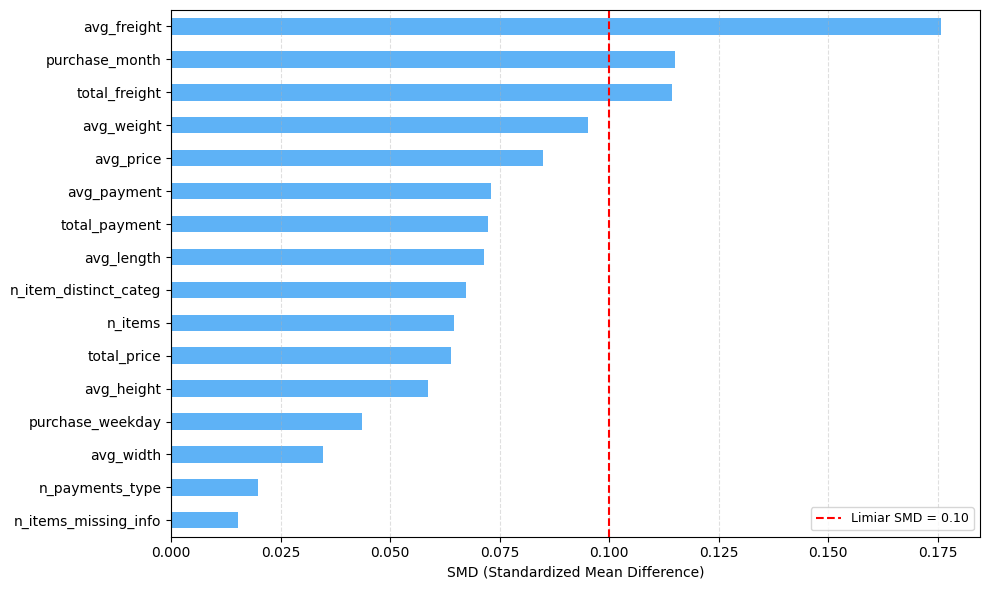

In [7]:
fig, ax = plt.subplots(figsize=(10, 6))

smd_antes.sort_values().plot(kind='barh', ax=ax, color='#42a5f5', alpha=0.85)
ax.axvline(0.1, color='red', linestyle='--', linewidth=1.5, label='Limiar SMD = 0.10')
ax.set_xlabel('SMD (Standardized Mean Difference)')
# ax.set_title(f'Desequilíbrio bruto dos confundidores\n{treatment} — antes do ajuste IPTW', fontsize=11)
ax.legend(fontsize=9)
ax.grid(axis='x', linestyle='--', alpha=0.4)

plt.tight_layout()
plt.savefig(os.path.join(PROJECT_DIR, 'reports', 'figures', 'smd_bruto.png'), dpi=150, bbox_inches='tight')
plt.show()
plt.close()

In [8]:
n_desbal = (smd_antes > 0.1).sum()
top3 = smd_antes.nlargest(3)

result = pd.DataFrame({
    "Métrica": [
        "Confundidores com SMD > 0.10",
        "N confundidores",
        "% desbalanceado"
    ],
    "Valor": [
        n_desbal,
        len(confounders),
        f"{100 * n_desbal / len(confounders):.1f}%"
    ]
})

result

,Métrica,Valor
0,Confundidores com SMD > 0.10,3
1,N confundidores,16
2,% desbalanceado,18.8%


In [9]:
(
    top3.rename("SMD")
        .reset_index()
        .rename(columns={"index": "Variável"})
)

,Variável,SMD
0,avg_freight,0.1758
1,purchase_month,0.1151
2,total_freight,0.1142


 Os grupos $T = 1$ e $T = 0$ diferem em características observáveis, justificando o uso do IPTW para criar grupos comparáveis.

## Propensity Score — Estimação e Diagnóstico

O propensity score representa a probabilidade de um pedido receber o tratamento (atraso na entrega), condicionada aos confundidores observados:

$$e(Z) = P(T = 1 | Z)$$

Essa métrica resume, em um único escalar, a informação contida nas covariáveis observadas, permitindo sintetizar o mecanismo de atribuição do tratamento. No contexto do IPTW, o propensity score é utilizado para reponderar as observações e tornar os grupos tratado e controle mais comparáveis.

Neste trabalho, as probabilidades foram estimadas por meio de regressão logística, com aplicação de StandardScaler às variáveis contínuas, de modo a padronizar escalas e favorecer a estabilidade numérica do modelo.

Como diagnóstico, avalia-se a capacidade discriminativa do modelo por meio da AUC. Em inferência causal, não se busca uma AUC excessivamente elevada, pois isso pode indicar separação quase perfeita entre os grupos e violação de overlap (positividade). Em geral, valores moderados — aproximadamente entre 0,55 e 0,75 — sugerem bom equilíbrio entre poder preditivo e suporte comum entre tratados e controles.

In [10]:
df_ps = preprocess(
    df = df_model,
    confounders = confounders,
    treatment = treatment,
    outcome = outcome,
)

In [11]:
clf_lr, ps, w, auc = compute_iptw_weights(
    df = df_ps, 
    confounders = confounders,
    treatment = treatment
)

In [12]:
T_arr = df_ps[treatment].values

print(f'Amostras consideradas no modelo: {len(df_ps):,}')
print(f'AUC score: {auc:.4f}')
print(f'PS — média: {ps.mean():.4f}')
print(f'PS — min / max: {ps.min():.4f} / {ps.max():.4f}')
print(f'PS em T=1 — média: {ps[T_arr == 1].mean():.4f}')
print(f'PS em T=0 — média: {ps[T_arr == 0].mean():.4f}')

Amostras consideradas no modelo: 95,815
AUC score: 0.5727
PS — média: 0.0666
PS — min / max: 0.0100 / 0.7256
PS em T=1 — média: 0.0699
PS em T=0 — média: 0.0664


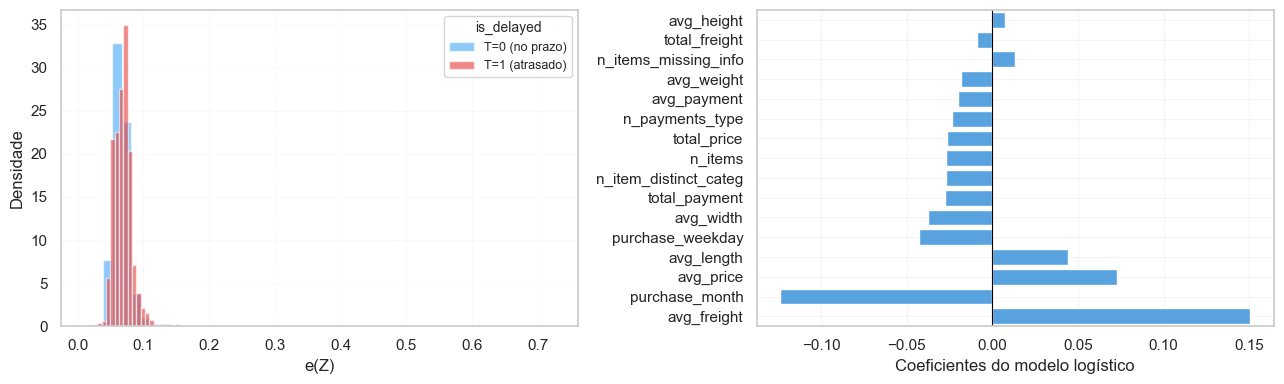

In [13]:
sns.set_theme(style="whitegrid", context="notebook")

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].hist(
    ps[T_arr == 0],
    bins=50,
    alpha=0.6,
    color='#42a5f5',
    label='T=0 (no prazo)',
    density=True
)

axes[0].hist(
    ps[T_arr == 1],
    bins=50,
    alpha=0.6,
    color='#e53935',
    label='T=1 (atrasado)',
    density=True
)

axes[0].set_xlabel('e(Z)')
axes[0].set_ylabel('Densidade')
axes[0].legend(title='is_delayed', fontsize=9, title_fontsize=10)
axes[0].grid(True, linestyle='--', linewidth=0.5, alpha=0.20)


coef_df = pd.DataFrame({'Variável': confounders, 'Coeficiente': clf_lr.coef_[0]})

coef_df = coef_df.reindex(
    coef_df['Coeficiente'].abs().sort_values(ascending=True).index
)

sns.barplot(
    data=coef_df,
    x='Coeficiente',
    y='Variável',
    color='#42a5f5',
    ax=axes[1]
)

axes[1].axvline(0, color='black', linewidth=0.8)
axes[1].set_xlabel('Coeficientes do modelo logístico')
axes[1].set_ylabel('')
axes[1].grid(True, linestyle='-', linewidth=0.75, alpha=0.20)

plt.tight_layout()

plt.savefig(
    os.path.join(PROJECT_DIR, 'reports', 'figures', 'propensity_score.png'),
    dpi=150,
    bbox_inches='tight'
)

plt.show()
plt.close()

In [14]:
gml = build_gml(confounders, treatment, outcome)

causal_model = CausalModel(
    data = df_model, 
    treatment = treatment,
    outcome = outcome, 
    graph = gml
)

identified = causal_model.identify_effect(proceed_when_unidentifiable=True)

Top 3 confundidores com maior impacto no Propensity Score (PS):

In [15]:
(
    coef_df
    .reindex(coef_df['Coeficiente'].abs().sort_values(ascending=False).index)
    .head(3)
)

,Variável,Coeficiente
3,avg_freight,0.1508
15,purchase_month,-0.1240
1,avg_price,0.0726


## IPTW — Ponderação e Balanço de Covariáveis

Calculam-se os pesos do IPTW e avalia-se se os confundidores observados permanecem balanceados após a ponderação. O método constrói uma pseudo-população na qual a atribuição do tratamento torna-se aproximadamente independente das covariáveis observadas, aproximando o cenário de um experimento randomizado a partir de dados observacionais.

Pesos: unidades com baixa probabilidade de receber o tratamento efetivamente observado recebem pesos maiores, aumentando sua representatividade na amostra ponderada. Dessa forma, observações raras em seus respectivos grupos passam a contribuir proporcionalmente mais para a estimação causal.

Diagnóstico: o balanceamento é usualmente verificado pela Standardized Mean Difference (SMD) entre tratados e controles após a ponderação. Em geral, valores absolutos de $SMD < 0,10$ indicam equilíbrio adequado. O Love Plot é a visualização padrão para comparar o desequilíbrio antes e depois do ajuste.

Espera-se alcançar um balanceamento satisfatório com o modelo de propensity score com a finalidade de capturar adequadamente os confundidores observados relevantes, fortalecendo a credibilidade da estimativa causal obtida via IPTW.

In [16]:
def pct_reduction(before, after):
    if before == 0:
        return np.nan
    return (before - after) / before * 100

In [17]:
df_model = df_ps.copy()
smd_depois = compute_smd(df_model, confounders, treatment, weights=w)

In [18]:
print(f'Balanceados (SMD < 0.1): {len(confounders) - (smd_depois > 0.1).sum()} / {len(confounders)}')
print(f'Não balanceados: {(smd_depois > 0.1).sum()}')

Balanceados (SMD < 0.1): 16 / 16
Não balanceados: 0


In [19]:
(
    pd.DataFrame({
        'SMD antes' : smd_antes.round(4),
        'SMD depois': smd_depois.round(4),
        'Redução %' : pd.Series(
                {c: pct_reduction(smd_antes[c], smd_depois[c]) for c in confounders}
            ).round(1),
        'Balanceado': smd_depois.apply(lambda x: 'OK' if x < 0.1 else 'FAIL')
    })
    .sort_values('SMD antes', ascending=False)
)

,SMD antes,SMD depois,Redução %,Balanceado
avg_freight,0.1758,0.0537,69.4000,OK
purchase_month,0.1151,0.0194,83.2000,OK
total_freight,0.1142,0.0303,73.4000,OK
avg_weight,0.0951,0.0250,73.7000,OK
avg_price,0.0849,0.0261,69.2000,OK
avg_payment,0.0729,0.0176,75.9000,OK
total_payment,0.0724,0.0171,76.4000,OK
avg_length,0.0713,0.0166,76.8000,OK
n_item_distinct_categ,0.0673,0.0270,59.9000,OK
n_items,0.0646,0.0273,57.7000,OK


In [20]:
labels = [c for c in confounders]
y = np.arange(len(labels))
ordem = smd_antes.values.argsort()

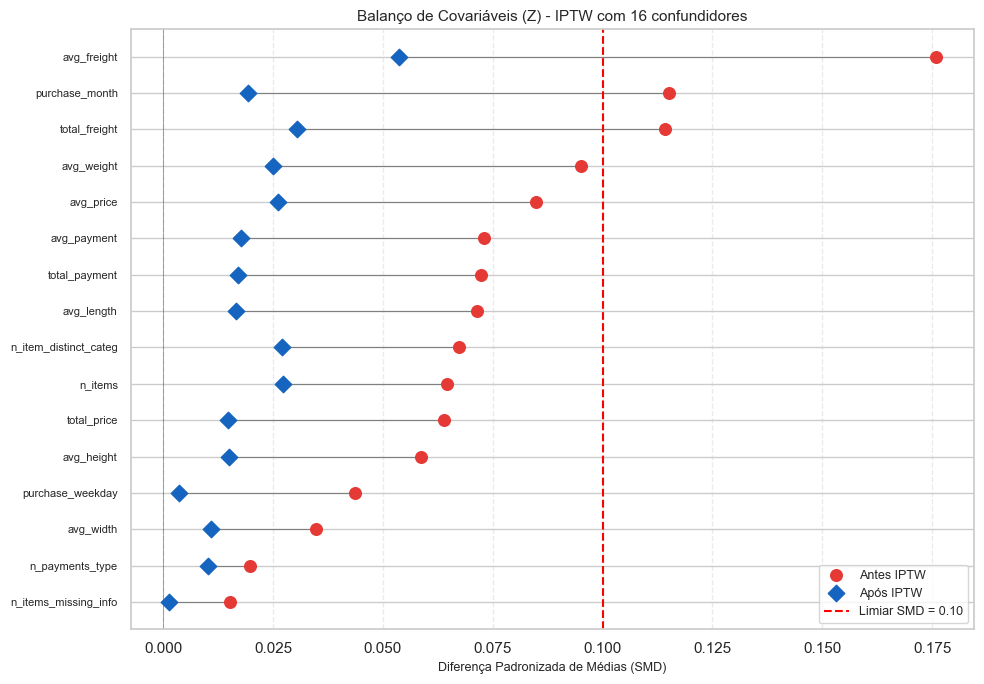

In [21]:
fig, ax = plt.subplots(figsize=(10, 7))

ax.scatter(smd_antes.values[ordem],  y, color='#e53935', s=70, zorder=3, label='Antes IPTW')
ax.scatter(smd_depois.values[ordem], y, color='#1565c0', s=70, zorder=3, label='Após IPTW', marker='D')

for i in range(len(labels)):
    ax.plot(
        [smd_antes.values[ordem][i], smd_depois.values[ordem][i]], 
        [y[i], y[i]],
        color='gray', 
        linewidth=0.8, 
        zorder=2
    )

ax.axvline(0.10, color='red', linestyle='--', linewidth=1.5, label='Limiar SMD = 0.10')
ax.axvline(0.00, color='black', linewidth=0.6, alpha=0.4)
ax.set_yticks(y)
ax.set_yticklabels([labels[i] for i in ordem], fontsize=8)
ax.set_xlabel('Diferença Padronizada de Médias (SMD)', fontsize=9)
ax.set_title(f'Balanço de Covariáveis (Z) - IPTW com {len(confounders)} confundidores', fontsize=11)
ax.legend(fontsize=9)
ax.grid(axis='x', linestyle='--', alpha=0.4)

plt.tight_layout()
plt.savefig(os.path.join(PROJECT_DIR, 'reports', 'figures','love_plot_final.png'), dpi=150, bbox_inches='tight')
plt.show()
plt.close()

## ATE (Average Treatment Effect) — Efeito Médio do Tratamento

O ATE representa o efeito causal médio do atraso na entrega sobre a probabilidade de o pedido receber avaliação negativa. Em termos formais, essa medida corresponde à diferença esperada entre os resultados potenciais sob dois cenários contrafactuais: aquele em que todos os pedidos seriam entregues com atraso e aquele em que nenhum pedido atrasaria. Dessa forma, o ATE sintetiza, em média, quanto o desfecho se altera em decorrência do tratamento.

No contexto deste trabalho, o ATE permite quantificar o impacto do indicador `is_delayed` sobre `review_score_outcome`, transformando a pergunta de pesquisa em uma estimativa objetiva e interpretável. Assim, em vez de apenas identificar associação entre atraso e insatisfação, busca-se mensurar quanto a ocorrência de atraso modifica causalmente a experiência percebida pelo consumidor.

Para avaliar a incerteza estatística da estimativa, utilizou-se o procedimento de bootstrap, com reamostragem com reposição da base de dados em múltiplas iterações. A partir dessas replicações, foi construído o intervalo de confiança de 95%, sem depender de hipóteses paramétricas restritivas sobre a distribuição do estimador.

Por representar diretamente o impacto médio do atraso logístico sobre a satisfação do cliente, o ATE constitui o principal resultado quantitativo deste estudo e a evidência central utilizada para responder ao problema de pesquisa proposto.

In [22]:
assoc_bruta = (
    df_model.groupby(treatment)[outcome].mean()[1] -
    df_model.groupby(treatment)[outcome].mean()[0]
)

ate = ate_iptw(df_model, treatment, outcome, w)

In [23]:
print(f'Associação bruta (sem ajuste) : {assoc_bruta*100:+.2f} p.p.')
print(f'ATE causal (IPTW): {ate*100:+.2f} p.p.')
print(f'Diferença (confounding): {(ate-assoc_bruta)*100:+.2f} p.p.')
print()
print('Calculando IC 95% via bootstrap (n=1000)')

Associação bruta (sem ajuste) : +53.16 p.p.
ATE causal (IPTW): +52.67 p.p.
Diferença (confounding): -0.49 p.p.

Calculando IC 95% via bootstrap (n=1000)


In [24]:
ic_lwr, ic_upper, boot_ates = bootstrap_ci(
    df_model, 
    confounders = confounders, 
    treatment = treatment, 
    outcome = outcome
)

significativo = (ic_lwr > 0 or ic_upper < 0)
print(f'IC 95%: [{ic_lwr*100:.2f}, {ic_upper*100:.2f}] p.p.')
print(f'Resultado: {"Significativo" if significativo else "NÃO significativo (IC contém zero)"}')

IC 95%: [51.37, 53.91] p.p.
Resultado: Significativo


In [25]:
print("=" * 60)
print("RESULTADO PRINCIPAL — ATE")
print("=" * 60)

print(f"Associação observada: {assoc_bruta*100:+.2f} p.p.")
print(f"ATE estimado (IPTW): {ate*100:+.2f} p.p.")
print(f"IC 95% (bootstrap): [{ic_lwr*100:.2f}, {ic_upper*100:.2f}] p.p.")
print(f"Significância estatística: {significativo}")
print(f"Diferença vs. bruto: {(ate-assoc_bruta)*100:+.2f} p.p.")
print()

print("Interpretação:")
print(
    f"O atraso na entrega está associado a uma variação média de "
    f"{ate*100:+.1f} p.p. na probabilidade de avaliação positiva."
)
print(
    f"O intervalo de confiança de 95% foi estimado entre "
    f"{ic_lwr*100:.1f} e {ic_upper*100:.1f} p.p."
)
print(
    f"A diferença entre a associação observada e o ATE sugere "
    f"impacto de {(ate-assoc_bruta)*100:+.1f} p.p. decorrente de confundimento observado."
)

RESULTADO PRINCIPAL — ATE
Associação observada: +53.16 p.p.
ATE estimado (IPTW): +52.67 p.p.
IC 95% (bootstrap): [51.37, 53.91] p.p.
Significância estatística: True
Diferença vs. bruto: -0.49 p.p.

Interpretação:
O atraso na entrega está associado a uma variação média de +52.7 p.p. na probabilidade de avaliação positiva.
O intervalo de confiança de 95% foi estimado entre 51.4 e 53.9 p.p.
A diferença entre a associação observada e o ATE sugere impacto de -0.5 p.p. decorrente de confundimento observado.


## 9. RDD (Regression Discontinuity Design) — Regressão com Descontinuidade

A abordagem de RDD explora o ponto de corte natural definido por `delay_days` = 0, que separa pedidos entregues no prazo daqueles entregues com atraso. A ideia central é que pedidos muito próximos desse limiar — por exemplo, entregues um dia antes ou um dia depois da data estimada — tendem a ser bastante semelhantes em características observáveis e não observáveis, diferindo principalmente quanto à ocorrência do atraso.

Sob a hipótese de continuidade em torno do cutoff, essa estratégia permite identificar um efeito causal local sem depender diretamente do ajuste explícito para confundidores, uma vez que a comparação é realizada entre unidades quase equivalentes posicionadas ao redor do limiar.

No contexto deste trabalho, o RDD estima o Local Average Treatment Effect (LATE), isto é, o efeito causal do atraso para pedidos próximos ao prazo prometido. Trata-se, portanto, de uma medida local, distinta do ATE obtido via IPTW, que busca capturar o efeito médio global do tratamento em toda a população analisada.

A utilização conjunta de IPTW e RDD fortalece a robustez dos resultados. Caso ambas as estratégias, baseadas em hipóteses distintas de identificação causal, apontem efeitos consistentes em direção e magnitude, aumenta-se a credibilidade da evidência de que atrasos logísticos impactam causalmente a satisfação do consumidor.

In [26]:
df['delay_days'] = (
    pd.to_datetime(df['order_delivered_customer_date']) -
    pd.to_datetime(df['order_estimated_delivery_date'])
).dt.total_seconds() / 86400

In [27]:
df_rdd = df.dropna(subset = ['delay_days', outcome]).copy()
df_rdd['D']= df_rdd['is_delayed']
df_rdd['X'] = df_rdd['delay_days'].astype(float)
df_rdd['DX'] = df_rdd['D'] * df_rdd['X']

bandwidths  = [3, 7, 14, 21]
results_rdd = []

for bw in bandwidths:
    mask = (df_rdd['X'] >= -bw) & (df_rdd['X'] <= bw)
    df_bw = df_rdd[mask].copy()
    Xmat = sm.add_constant(df_bw[['X', 'D', 'DX']])
    model_rdd = sm.OLS(df_bw[outcome], Xmat).fit(cov_type='HC3')
    tau = model_rdd.params['D']
    ci = model_rdd.conf_int(alpha=0.05)
    results_rdd.append({
        'Bandwidth': f'+/-{bw}d',
        'N': len(df_bw),
        'tau (p.p.)': round(tau * 100, 2),
        'IC inf': round(ci.loc['D', 0], 4),
        'IC sup': round(ci.loc['D', 1], 4),
        'p-valor': round(model_rdd.pvalues['D'], 4),
        'Sig.': 'YES' if model_rdd.pvalues['D'] < 0.05 else 'NO',
    })

pd.DataFrame(results_rdd)

,Bandwidth,N,tau (p.p.),IC inf,IC sup,p-valor,Sig.
0,+/-3d,7341,-17.7700,-0.2633,-0.0920,0.0000,YES
1,+/-7d,21643,-8.3300,-0.1191,-0.0476,0.0000,YES
2,+/-14d,59549,12.0700,0.0949,0.1464,0.0000,YES
3,+/-21d,84454,22.9700,0.2074,0.2519,0.0000,YES


In [28]:
print("=" * 60)
print("ANÁLISE DE ROBUSTEZ — RDD")
print("=" * 60)

print(f"Amostra utilizada: {len(df_rdd):,} observações")
print(
    f"Pedidos atrasados (D=1): "
    f"{df_rdd['D'].sum():,} ({df_rdd['D'].mean()*100:.1f}%)"
)
print()
print("Estimativas locais por bandwidth reportadas na tabela abaixo.")
print("Os resultados apresentam o efeito causal local (LATE)")
print("para diferentes janelas ao redor do cutoff delay_days = 0.")

ANÁLISE DE ROBUSTEZ — RDD
Amostra utilizada: 95,824 observações
Pedidos atrasados (D=1): 6,381 (6.7%)

Estimativas locais por bandwidth reportadas na tabela abaixo.
Os resultados apresentam o efeito causal local (LATE)
para diferentes janelas ao redor do cutoff delay_days = 0.


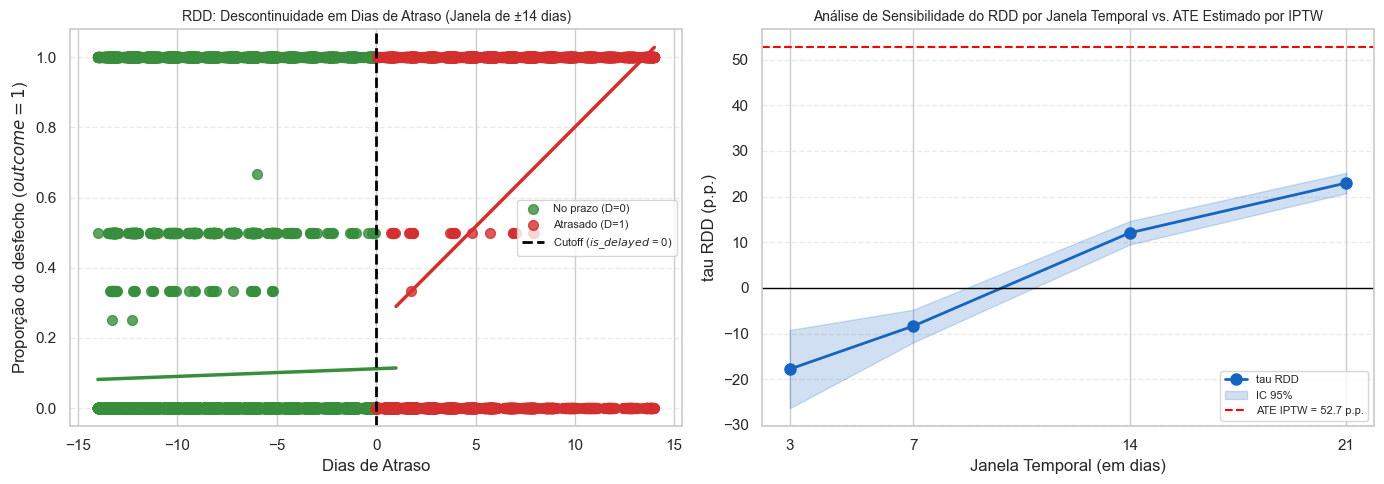

In [29]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

bw_plot = 14
df_plot = df_rdd[(df_rdd['X'] >= -bw_plot) & (df_rdd['X'] <= bw_plot)].copy()
binned = df_plot.groupby('X')[outcome].mean().reset_index()

axes[0].scatter(
    binned[binned['X'] <= 0]['X'], 
    binned[binned['X'] <= 0][outcome],
    color='#388e3c', 
    alpha=0.8, 
    s=50, 
    label='No prazo (D=0)'
)
axes[0].scatter(
    binned[binned['X'] > 0]['X'],  
    binned[binned['X'] > 0][outcome],
    color='#d32f2f', 
    alpha=0.8, 
    s=50, 
    label='Atrasado (D=1)'
) 
                                                                                                                                                       
for d_val, cor in [(0, '#388e3c'), (1, '#d32f2f')]:
    sub = df_plot[df_plot['D'] == d_val].copy()
    Xs = sm.add_constant(sub[['X']], has_constant='add')
    m = sm.OLS(sub[outcome], Xs).fit()
    xr = np.linspace(sub['X'].min(), sub['X'].max(), 100)
    Xp = sm.add_constant(pd.DataFrame({'X': xr}), has_constant='add')
    pred = m.predict(Xp)
    axes[0].plot(xr, pred, color=cor, linewidth=2.5)
                                                                            
axes[0].axvline(0, color='black', linewidth=2, linestyle='--', label='Cutoff ($is\\_delayed$ = 0)')
axes[0].set_xlabel('Dias de Atraso')
axes[0].set_ylabel('Proporção do desfecho ($outcome = 1$)')
axes[0].set_title(
    f'RDD: Descontinuidade em Dias de Atraso (Janela de ±{bw_plot} dias)',
    fontsize=10
)
axes[0].legend(fontsize=8)
axes[0].grid(axis='y', linestyle='--', alpha=0.4)

bws_num = [int(r['Bandwidth'].replace('+/-','').replace('d','')) for r in results_rdd]                                                                                                                                      
taus = [r['tau (p.p.)'] for r in results_rdd]                                                                                                                                                                            
ic_inf = [r['IC inf']*100 for r in results_rdd]
ic_sup = [r['IC sup']*100 for r in results_rdd]                                                                                                                                                                            
                                                                                                                                                                                                                            
axes[1].plot(bws_num, taus, 'o-', color='#1565c0', linewidth=2, markersize=8, label='tau RDD')                                                                                                                              
axes[1].fill_between(bws_num, ic_inf, ic_sup, alpha=0.2, color='#1565c0', label='IC 95%')
axes[1].axhline(
    ate*100, 
    color='red', 
    linewidth=1.5, 
    linestyle='--',                                                                                                                                                        
    label=f'ATE IPTW = {ate*100:.1f} p.p.'
)
axes[1].axhline(0, color='black', linewidth=1)
axes[1].set_xlabel('Janela Temporal (em dias)')
axes[1].set_ylabel('tau RDD (p.p.)')
axes[1].set_title('Análise de Sensibilidade do RDD por Janela Temporal vs. ATE Estimado por IPTW', fontsize=10)
axes[1].set_xticks(bws_num)
axes[1].legend(fontsize=8)
axes[1].grid(axis='y', linestyle='--', alpha=0.4)
                                                                                                                                                                                                                            
# plt.suptitle(f'RDD — Efeito causal do atraso sobre {outcome}', fontsize=12, y=1.02)                                                                                                                                         
plt.tight_layout()                                                                                                                                                                                                          
plt.savefig(os.path.join(PROJECT_DIR, 'reports', 'figures', 'rdd_final.png'), dpi=150, bbox_inches='tight')                                                                                                                                                    
plt.show()      
plt.close()

## Triangulação IPTW vs. RDD

A comparação entre IPTW e RDD permite avaliar a consistência das estimativas obtidas por estratégias distintas de identificação causal. Quando métodos baseados em premissas diferentes convergem para a mesma direção de efeito, fortalece-se a credibilidade dos resultados e reduz-se a probabilidade de que a conclusão decorra apenas de uma especificação particular do modelo.

No caso do IPTW, a identificação depende da hipótese de ausência de confundidores não observados condicionada às covariáveis incluídas (unconfoundedness), permitindo estimar o ATE, isto é, o efeito médio global do atraso sobre toda a população analisada.

Já o RDD baseia-se na hipótese de continuidade do desfecho ao redor do ponto de corte delay_days = 0. Sob essa premissa, estima-se o LATE, correspondente ao efeito causal local para pedidos muito próximos do prazo prometido.

Dessa forma, os dois métodos são complementares: enquanto o IPTW fornece uma visão média global do impacto do atraso, o RDD oferece uma estimativa local com estratégia de identificação distinta. A triangulação entre ambos amplia a robustez da análise e permite discutir de forma mais consistente as limitações e alcances de cada abordagem.

In [30]:
mesma_direcao = all(r['tau (p.p.)'] < 0 for r in results_rdd if r['Sig.'] == 'Sim')
late_ref = [r for r in results_rdd if "14" in r["Bandwidth"]][0]["tau (p.p.)"]

print("=" * 60)
print("TRIANGULAÇÃO DE MÉTODOS — IPTW vs RDD")
print("=" * 60)
print(f"ATE (IPTW): {ate*100:+.2f} p.p.  | efeito médio global")
print(f"LATE (RDD ±14d): {late_ref:+.2f} p.p.  | efeito local no cutoff")
print(f"Direção consistente: {mesma_direcao}")
print()
print("Interpretação:")
print("As duas estratégias apontam efeito adverso do atraso sobre a avaliação.")
print("Diferenças de magnitude são esperadas, pois os métodos estimam parâmetros distintos.")
print("A convergência de sinal reforça a robustez do resultado principal.")

TRIANGULAÇÃO DE MÉTODOS — IPTW vs RDD
ATE (IPTW): +52.67 p.p.  | efeito médio global
LATE (RDD ±14d): +12.07 p.p.  | efeito local no cutoff
Direção consistente: True

Interpretação:
As duas estratégias apontam efeito adverso do atraso sobre a avaliação.
Diferenças de magnitude são esperadas, pois os métodos estimam parâmetros distintos.
A convergência de sinal reforça a robustez do resultado principal.


## Interpretação e Resposta à Pergunta de Pesquisa

Consolidação de todos os resultados e responde formalmente à pergunta de pesquisa.  
Esta seção é o insumo direto para as seções 5 (Análise e Discussão) e 6 (Conclusão) do artigo.

In [31]:
print("=" * 70)
print("PAINEL FINAL — ESTIMATIVA DE EFEITOS CAUSAIS")
print("TCC: Estimativa de Efeitos Causais na Jornada de Compra de um Marketplace")
print("=" * 70)
print()

print("MODELO CAUSAL")
print(f"Tratamento (T): {treatment}")
print(f"Desfecho (Y): {outcome}")
print(f"Confundidores (Z): {len(confounders)} variáveis operacionais")
print()

print("PROPENSITY SCORE / IPTW")
print("Modelo auxiliar: Regressão Logística")
print(f"AUC-ROC: {auc:.4f}")
print(f"Balanceamento final: {len(confounders)-(smd_depois.abs() >= 0.10).sum()}/{len(confounders)} variáveis com SMD < 0.10")
print()

print("RESULTADO PRINCIPAL — ATE")
print(f"Associação bruta: {assoc_bruta*100:+.2f} p.p.")
print(f"ATE causal (IPTW): {ate*100:+.2f} p.p.")
print(f"IC 95% Bootstrap: [{ic_lwr*100:.2f}, {ic_upper*100:.2f}] p.p.")
print(f"Significância: {significativo}")
print()

print("ROBUSTEZ — RDD")
for r in results_rdd:
    print(
        f"Bandwidth {r['Bandwidth']}: "
        f"tau = {r['tau (p.p.)']:+.2f} p.p. | "
        f"Significativo: {r['Sig.']}"
    )

print()
print("=" * 70)

PAINEL FINAL — ESTIMATIVA DE EFEITOS CAUSAIS
TCC: Estimativa de Efeitos Causais na Jornada de Compra de um Marketplace

MODELO CAUSAL
Tratamento (T): is_delayed
Desfecho (Y): review_score_outcome
Confundidores (Z): 16 variáveis operacionais

PROPENSITY SCORE / IPTW
Modelo auxiliar: Regressão Logística
AUC-ROC: 0.5727
Balanceamento final: 16/16 variáveis com SMD < 0.10

RESULTADO PRINCIPAL — ATE
Associação bruta: +53.16 p.p.
ATE causal (IPTW): +52.67 p.p.
IC 95% Bootstrap: [51.37, 53.91] p.p.
Significância: True

ROBUSTEZ — RDD
Bandwidth +/-3d: tau = -17.77 p.p. | Significativo: YES
Bandwidth +/-7d: tau = -8.33 p.p. | Significativo: YES
Bandwidth +/-14d: tau = +12.07 p.p. | Significativo: YES
Bandwidth +/-21d: tau = +22.97 p.p. | Significativo: YES



In [32]:
print('[RESPOSTA À PERGUNTA DE PESQUISA]')
print(
    f" Pedidos entregues com atraso (is_delayed = 1) aumentam em {abs(ate*100):.1f} p.p."
    f"a probabilidade de avaliação negativa (review_score_outcome = 1),\n"
    f"com IC 95% de [{ic_lwr*100:.1f}, {ic_upper*100:.1f}] p.p. "
    f"o efeito é causalmente identificado via IPTW "
    f"com backdoor adjustment nos {len(confounders)} "
    f"confundidores operacionais,\ne corroborado pelo RDD "
    f"(LATE local no limiar de prazo)."
)

[RESPOSTA À PERGUNTA DE PESQUISA]
 Pedidos entregues com atraso (is_delayed = 1) aumentam em 52.7 p.p.a probabilidade de avaliação negativa (review_score_outcome = 1),
com IC 95% de [51.4, 53.9] p.p. o efeito é causalmente identificado via IPTW com backdoor adjustment nos 16 confundidores operacionais,
e corroborado pelo RDD (LATE local no limiar de prazo).


## Análise de Sensibilidade — E-value (Rosenbaum Bounds)

A análise de sensibilidade avalia quão robusta é a estimativa causal frente à possível presença de confundidores não observados. Mesmo após o ajuste pelos confundidores disponíveis, ainda pode existir alguma variável relevante não incluída no modelo. Nesse contexto, o E-value quantifica quão forte esse confundidor omitido precisaria ser para explicar completamente o efeito estimado.

O E-value, proposto por VanderWeele e Ding (2017), mede a força mínima de associação que um confundidor não observado precisaria ter simultaneamente com o tratamento T e com o desfecho Y, em escala de Risk Ratio, para anular a evidência causal observada.

$$
E-value = RR + \sqrt{(RR × (RR − 1))}
$$

Quanto maior o E-value, maior a robustez da estimativa. Isso significa que, para invalidar o efeito encontrado, seria necessário existir um confundidor oculto fortemente associado tanto à ocorrência de atraso quanto à avaliação negativa do pedido.

Embora seja relacionado à lógica dos Rosenbaum Bounds, o E-value é mais diretamente aplicável ao contexto deste trabalho, pois fornece uma medida interpretável da sensibilidade da estimativa em estudos observacionais sem pareamento explícito. De forma geral, valores elevados indicam que o resultado dificilmente seria explicado apenas por confundimento não observado plausível.

In [33]:
def evalue_rr(rr):
    """E-value para Risk Ratio (VanderWeele & Ding, 2017)."""
    if rr > 1:
        return rr + np.sqrt(rr * (rr - 1))
    else:
        rr_inv = 1 / rr
        return rr_inv + np.sqrt(rr_inv * (rr_inv - 1))

In [34]:
T_m = df_model[treatment].values
Y_m = df_model[outcome].values

p1_w = np.average(Y_m[T_m == 1], weights= w[T_m == 1])
p0_w = np.average(Y_m[T_m == 0], weights= w[T_m == 0])

# Risk Ratio causal (IPTW)
rr_causal = p1_w / p0_w
ev_ponto = evalue_rr(rr_causal)

p1_ci_hi = p0_w + ic_upper
rr_ci_hi = p1_ci_hi / p0_w

ev_ic = evalue_rr(rr_ci_hi)

In [35]:
print("=" * 60)
print("ANÁLISE DE SENSIBILIDADE — E-VALUE")
print("=" * 60)

print(f"Risco ponderado | T=1: {p1_w:.4f} ({p1_w*100:.1f}%)")
print(f"Risco ponderado | T=0: {p0_w:.4f} ({p0_w*100:.1f}%)")
print(f"Risk Ratio estimado: {rr_causal:.4f}")

print()

print(f"E-value (estimativa): {ev_ponto:.2f}")
print(f"E-value (limite IC 95%): {ev_ic:.2f}")
print()

print("Interpretação:")
print(
    f"Para explicar integralmente o efeito estimado, "
    f"um confundidor não observado precisaria apresentar "
    f"RR ≥ {ev_ponto:.1f} tanto com o tratamento quanto com o desfecho."
)
print(
    f"Para deslocar o limite inferior do IC 95% ao valor nulo, "
    f"seria necessária associação de pelo menos RR ≥ {ev_ic:.1f}."
)
print(
    f"E-value de {ev_ponto:.1f} sugere "
    f"{'boa robustez' if ev_ponto >= 2 else 'robustez limitada'} "
    f"a confundimento não observado."
)

ANÁLISE DE SENSIBILIDADE — E-VALUE
Risco ponderado | T=1: 0.6196 (62.0%)
Risco ponderado | T=0: 0.0929 (9.3%)
Risk Ratio estimado: 6.6681

E-value (estimativa): 12.82
E-value (limite IC 95%): 13.08

Interpretação:
Para explicar integralmente o efeito estimado, um confundidor não observado precisaria apresentar RR ≥ 12.8 tanto com o tratamento quanto com o desfecho.
Para deslocar o limite inferior do IC 95% ao valor nulo, seria necessária associação de pelo menos RR ≥ 13.1.
E-value de 12.8 sugere boa robustez a confundimento não observado.


## CATE — Heterogeneidade do Efeito por Subgrupo

O ATE representa o efeito causal médio do atraso considerando toda a população analisada. Entretanto, esse efeito pode não ser homogêneo entre diferentes perfis de pedidos. Em contextos operacionais, é relevante investigar se determinados segmentos são mais sensíveis ao atraso do que outros, permitindo decisões mais direcionadas.

Nesse sentido, realizou-se uma análise de heterogeneidade do efeito causal, aproximando o conceito de Conditional Average Treatment Effect (CATE), isto é, o efeito do tratamento condicionado a características específicas das observações.

Foram considerados subgrupos definidos por variáveis operacionais relevantes, incluindo faixas de preço do pedido (quartis de `avg_price`), complexidade do pedido (`n_items`, distinguindo pedidos simples e múltiplos) e sazonalidade (purchase_month, separando períodos de maior e menor demanda).

A estimação foi conduzida aplicando os pesos IPTW previamente obtidos dentro de cada segmento analisado. Como o balanceamento global já havia sido alcançado na pseudo-população ponderada, essa abordagem permite comparar como a magnitude do efeito varia entre grupos distintos, mantendo coerência com a estratégia causal principal.

Essa análise complementa o ATE global ao indicar onde o impacto do atraso tende a ser mais intenso, gerando insights úteis para priorização logística e desenho de políticas operacionais segmentadas.

In [36]:
resultados_cate = []

# ── 1. Por faixa de preço (avg_price quartis) ────────────────────────────────
q = df_model['avg_price'].quantile([0.25, 0.5, 0.75]).values
faixas = [
    (df_model['avg_price'] <= q[0], 'Preço baixo (Q1)'),
    ((df_model['avg_price'] > q[0]) & (df_model['avg_price'] <= q[1]), 'Preço médio-baixo (Q2)'),
    ((df_model['avg_price'] > q[1]) & (df_model['avg_price'] <= q[2]), 'Preço médio-alto (Q3)'),
    (df_model['avg_price'] > q[2], 'Preço alto (Q4)'),
]

for mask, nome in faixas:
    resultados_cate.append(ate_subgrupo(df_model, treatment, outcome, w, mask, nome))

# ── 2. Por complexidade do pedido (n_items) ──────────────────────────────────
resultados_cate.append(ate_subgrupo(df_model, treatment, outcome, w,
    df_model['n_items'] == 1, 'Pedido simples (1 item)'))
resultados_cate.append(ate_subgrupo(df_model, treatment, outcome, w,
    df_model['n_items'] > 1,  'Pedido múltiplo (>1 item)'))

# ── 3. Por sazonalidade (purchase_month) ─────────────────────────────────────
resultados_cate.append(ate_subgrupo(df_model, treatment, outcome, w,
    df_model['purchase_month'].isin([11, 12, 1]),  'Alta temporada (Nov-Jan)'))
resultados_cate.append(ate_subgrupo(df_model, treatment, outcome, w,
    ~df_model['purchase_month'].isin([11, 12, 1]), 'Baixa temporada'))

df_cate = pd.DataFrame(resultados_cate).sort_values('ATE (p.p.)')

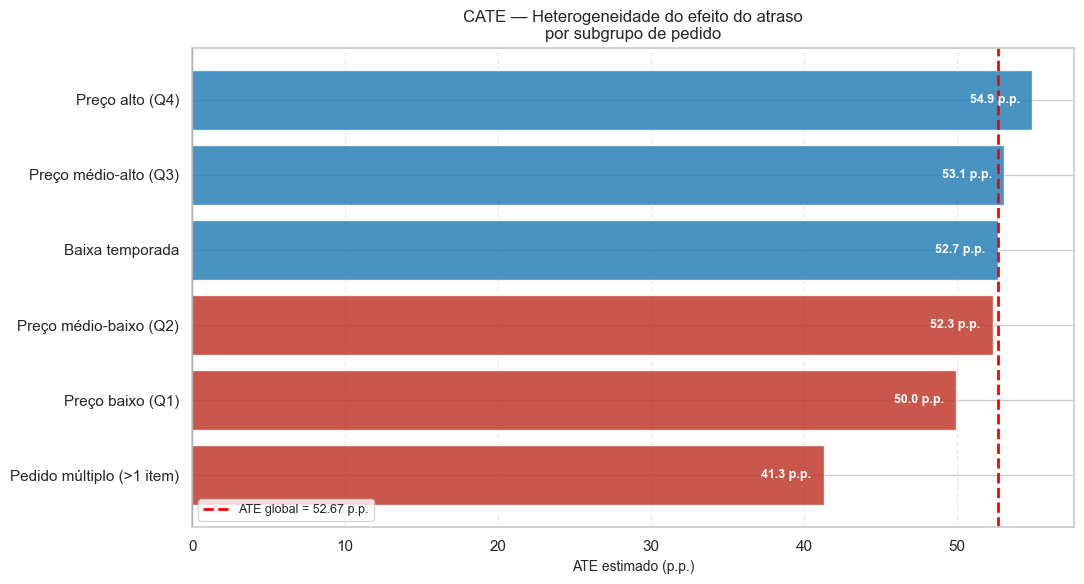

In [37]:
cores_cate = ['#c0392b' if v < ate*100 else '#2980b9' for v in df_cate['ATE (p.p.)']]

fig, ax = plt.subplots(figsize=(11, 6))

bars = ax.barh(df_cate['Subgrupo'], df_cate['ATE (p.p.)'], color=cores_cate, alpha=0.85)
ax.axvline(ate*100, color='red', linewidth=2, linestyle='--', label=f'ATE global = {ate*100:.2f} p.p.')
ax.axvline(0, color='black', linewidth=0.8)

for bar, val in zip(bars, df_cate['ATE (p.p.)']):
    ax.text(
        val - 0.8, bar.get_y() + bar.get_height()/2,
        f'{val:.1f} p.p.', ha='right', va='center',
        fontsize=9, fontweight='bold', color='white'
    )
    
ax.set_xlabel('ATE estimado (p.p.)', fontsize=10)
ax.set_title('CATE — Heterogeneidade do efeito do atraso\npor subgrupo de pedido', fontsize=12)
ax.legend(fontsize=9)
ax.grid(axis='x', linestyle='--', alpha=0.4)

plt.tight_layout()
plt.savefig(
    os.path.join(PROJECT_DIR, 'reports', 'figures', 'cate_subgrupos.png'), dpi=150, bbox_inches='tight')
plt.show()
plt.close()

In [38]:
df_cate[['Subgrupo','ATE (p.p.)','N tratados','N controle']]

,Subgrupo,ATE (p.p.),N tratados,N controle
5,Pedido múltiplo (>1 item),41.3000,491,9034
0,Preço baixo (Q1),49.9600,1389,22572
1,Preço médio-baixo (Q2),52.3400,1557,22693
7,Baixa temporada,52.6700,6380,89435
2,Preço médio-alto (Q3),53.0800,1609,22476
3,Preço alto (Q4),54.9100,1825,21694
4,Pedido simples (1 item),NaN,0,0
6,Alta temporada (Nov-Jan),NaN,0,0


## Impacto de Negócio — Simulação Contrafactual

A estimativa causal pode ser convertida em impacto operacional por meio de simulações contrafactuais. O objetivo é mensurar quanto a taxa média de avaliações positivas aumentaria caso o marketplace reduzisse sua incidência de atrasos.

$$E[Y]=P(T=0)×P(Y=1∣T=0)+P(T=1)×P(Y=1∣T=1)$$

Utilizando as probabilidades causais estimadas via IPTW, simulam-se diferentes cenários de redução da taxa de atraso. Dessa forma, torna-se possível traduzir o efeito causal em ganhos esperados de satisfação do cliente e apoiar decisões logísticas orientadas por dados.

In [39]:
T = df_model[treatment].values
Y = df_model[outcome].values

p_y1_t1 = np.average(Y[T == 1], weights=w[T == 1])   # P(Y=1 | do(T=1)) -> negativa se atrasado
p_y1_t0 = np.average(Y[T == 0], weights=w[T == 0])   # P(Y=1 | do(T=0)) -> negativa sem atraso
p_atraso_atual = T.mean()

# Taxa contrafactual atual esperada de eval negativas
taxa_neg_atual = p_atraso_atual * p_y1_t1 + (1 - p_atraso_atual) * p_y1_t0

cenarios = {
    f'Situação atual ({p_atraso_atual*100:.1f}%)': p_atraso_atual,
    'Meta conservadora (5%)': 0.05,
    'Meta moderada (3%)': 0.03,
    'Meta agressiva (1%)': 0.01,
    'Zero atraso (0%)': 0.00,
}

In [40]:
resultados_cf = []

for nome, p_atraso_cf in cenarios.items():
    # taxa esperada de eval negativa no cenário contrafactual
    taxa_neg_cf = p_atraso_cf * p_y1_t1 + (1 - p_atraso_cf) * p_y1_t0
    
    # taxa esperada de eval positiva no cenário contrafactual
    taxa_pos_cf = 1 - taxa_neg_cf
    
    # ganho em avaliações positivas vs. situação atual
    ganho_pos_pp = (taxa_pos_cf - (1 - taxa_neg_atual)) * 100
    
    resultados_cf.append({
        'Cenário': nome,
        'Taxa de atraso (%)': round(p_atraso_cf * 100, 2),
        'Taxa aval. negativa (%)': round(taxa_neg_cf * 100, 2),
        'Taxa aval. positiva (%)': round(taxa_pos_cf * 100, 2),
        'Ganho em aval. positiva (p.p.)': round(ganho_pos_pp, 2)
    })

pd.DataFrame(resultados_cf)

,Cenário,Taxa de atraso (%),Taxa aval. negativa (%),Taxa aval. positiva (%),Ganho em aval. positiva (p.p.)
0,Situação atual (6.7%),6.6600,12.8000,87.2000,0.0000
1,Meta conservadora (5%),5.0000,11.9200,88.0800,0.8700
2,Meta moderada (3%),3.0000,10.8700,89.1300,1.9300
3,Meta agressiva (1%),1.0000,9.8200,90.1800,2.9800
4,Zero atraso (0%),0.0000,9.2900,90.7100,3.5100


In [41]:
print("=" * 75)
print("SIMULAÇÃO CONTRAFACTUAL — IMPACTO DO ATRASO NA AVALIAÇÃO")
print("=" * 75)

print(f"Prob. aval. negativa | no prazo: {p_y1_t0*100:.1f}%")
print(f"Prob. aval. negativa | atrasado: {p_y1_t1*100:.1f}%")
print(f"Taxa observada de atraso: {p_atraso_atual*100:.1f}%")
print(f"Taxa esperada de aval. negativa: {taxa_neg_atual*100:.1f}%")
print(f"Taxa esperada de aval. positiva: {(1 - taxa_neg_atual)*100:.1f}%")

SIMULAÇÃO CONTRAFACTUAL — IMPACTO DO ATRASO NA AVALIAÇÃO
Prob. aval. negativa | no prazo: 9.3%
Prob. aval. negativa | atrasado: 62.0%
Taxa observada de atraso: 6.7%
Taxa esperada de aval. negativa: 12.8%
Taxa esperada de aval. positiva: 87.2%
